(1) Data Preprocessing & Cleaning

In [32]:
import pandas as pd
import numpy as np

file_path = 'multi_platform_social_sentiment_evolution.csv'

try:
    df = pd.read_csv(file_path)
    print("--- Đọc file thành công! ---")
except FileNotFoundError:
    print("Không tìm thấy file. Hãy kiểm tra lại đường dẫn.")

print("\nThông tin Dataset:")
print(df.info())


--- Đọc file thành công! ---

Thông tin Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   post_id                           150000 non-null  object 
 1   platform                          150000 non-null  object 
 2   timestamp                         150000 non-null  object 
 3   date                              150000 non-null  object 
 4   hour_of_day                       150000 non-null  int64  
 5   day_of_week                       150000 non-null  int64  
 6   is_weekend                        150000 non-null  int64  
 7   user_id                           150000 non-null  object 
 8   followers                         150000 non-null  int64  
 9   account_age_days                  150000 non-null  int64  
 10  verified                          150000 non-null  int64  
 11  top

In [2]:

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   post_id                           150000 non-null  object 
 1   platform                          150000 non-null  object 
 2   timestamp                         150000 non-null  object 
 3   date                              150000 non-null  object 
 4   hour_of_day                       150000 non-null  int64  
 5   day_of_week                       150000 non-null  int64  
 6   is_weekend                        150000 non-null  int64  
 7   user_id                           150000 non-null  object 
 8   followers                         150000 non-null  int64  
 9   account_age_days                  150000 non-null  int64  
 10  verified                          150000 non-null  int64  
 11  topic                             150000 non-null  o

In [3]:
print(df.columns)

Index(['post_id', 'platform', 'timestamp', 'date', 'hour_of_day',
       'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days',
       'verified', 'topic', 'language', 'content_length', 'media_type',
       'num_hashtags', 'sentiment_category', 'sentiment_positive',
       'sentiment_negative', 'sentiment_neutral', 'likes', 'shares',
       'comments', 'views', 'total_engagement',
       'engagement_rate_per_1k_followers', 'hours_since_post',
       'viral_coefficient', 'cross_platform_spread', 'toxicity_score',
       'location'],
      dtype='object')


1.1 parse datetime

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Extract additional time features (optional)
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month

1.2 Feature Transformation

In [5]:
df['log_followers'] = np.log1p(df['followers'])

In [6]:
# =========================
# 6. DEFINE FEATURE GROUPS
# =========================

categorical_cols = [
    'platform',
    'topic',
    'language',
    'media_type',
    'sentiment_category',
    'location'
]

numerical_cols = [
    'log_followers',
    'account_age_days',
    'content_length',
    'num_hashtags',
    'sentiment_positive',
    'sentiment_negative',
    'sentiment_neutral',
    'hour_of_day',
    'day_of_week',
    'is_weekend',
    'hours_since_post',
    'toxicity_score'
]


In [7]:
# =========================
# 7. SCALING + ENCODING PIPELINE
# =========================
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [8]:
# =========================
# 8. APPLY TRANSFORM
# =========================

X = preprocessor.fit_transform(df)

print("Processed feature shape:", X.shape)



Processed feature shape: (150000, 58)


In [9]:
# =========================
# 9. SAVE PREPROCESSOR (IMPORTANT)
# =========================
import joblib
joblib.dump(preprocessor, "preprocessor.pkl")

print("Preprocessing done ✅")

Preprocessing done ✅


1.3 Target Engineering

In [10]:
# =========================
# 1. DEFINE TARGET (REGRESSION)
# =========================

# Target chính
df['target_engagement'] = df['engagement_rate_per_1k_followers']

In [11]:
# =========================
# 2. CLASSIFICATION LABEL (OPTIONAL)
# =========================

# dùng percentile để chia high / low engagement
threshold = df['target_engagement'].quantile(0.8)

df['label'] = (df['target_engagement'] > threshold).astype(int)

print("Threshold:", threshold)
print(df['label'].value_counts())

Threshold: 40.0
label
0    120012
1     29988
Name: count, dtype: int64


In [12]:
drop_cols = [
    'post_id',
    'timestamp',
]

df = df.drop(columns=drop_cols)

In [14]:
leakage_cols = [
    'likes',
    'shares',
    'comments',
    'total_engagement',
    'views',
    'engagement_rate_per_1k_followers',
    'viral_coefficient'
]

df = df.drop(columns=leakage_cols)

print("Remaining columns:", df.columns)

Remaining columns: Index(['platform', 'date', 'hour_of_day', 'day_of_week', 'is_weekend',
       'user_id', 'followers', 'account_age_days', 'verified', 'topic',
       'language', 'content_length', 'media_type', 'num_hashtags',
       'sentiment_category', 'sentiment_positive', 'sentiment_negative',
       'sentiment_neutral', 'hours_since_post', 'cross_platform_spread',
       'toxicity_score', 'location', 'hour', 'day', 'month', 'log_followers',
       'target_engagement', 'label'],
      dtype='object')


In [21]:
# ---- Regression ----
y_reg = df['target_engagement']

# ---- Classification ----
y_clf = df['label']

# X = tất cả trừ target + label
X_df = df.drop(columns=['target_engagement', 'label'])

print("X shape:", X_df.shape)
print("y_reg shape:", y_reg.shape)
print("y_clf shape:", y_clf.shape)

X shape: (150000, 26)
y_reg shape: (150000,)
y_clf shape: (150000,)


2.Train / split

In [22]:
# preprocess
X_processed = preprocessor.fit_transform(X_df)

# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X_processed, y_reg, y_clf, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (120000, 58)
Test shape: (30000, 58)


BASELINE 1: MEAN PREDICTION

In [25]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# predict mean
mean_value = y_train_reg.mean()
y_pred_mean = np.full_like(y_test_reg, mean_value)

# evaluate
mae = mean_absolute_error(y_test_reg, y_pred_mean)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_mean))

print("Baseline 1 (Mean):")
print("MAE:", mae)
print("RMSE:", rmse)

Baseline 1 (Mean):
MAE: 82.18655074757777
RMSE: 312.13167326373366


BASELINE 2: LINEAR REGRESSION

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model_lr = LinearRegression()
model_lr.fit(X_train, y_train_reg)

y_pred_lr = model_lr.predict(X_test)

print("\nBaseline 2 (Linear Regression):")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)))
print("R2:", r2_score(y_test_reg, y_pred_lr))


Baseline 2 (Linear Regression):
MAE: 82.08769790129003
RMSE: 312.2093330997923
R2: -0.0004995211783083153


BASELINE 3: LOGISTIC REGRESSION (CLASSIFICATION)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train_clf)

y_pred_clf = model_log.predict(X_test)
y_prob = model_log.predict_proba(X_test)[:, 1]

print("\nBaseline 3 (Logistic Regression):")
print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print("F1-score:", f1_score(y_test_clf, y_pred_clf))
print("ROC-AUC:", roc_auc_score(y_test_clf, y_prob))


Baseline 3 (Logistic Regression):
Accuracy: 0.8017
F1-score: 0.0
ROC-AUC: 0.5630579913185125


A. TRAIN XGBOOST (FIX IMBALANCE)

In [67]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# =========================
# 1. CALCULATE CLASS WEIGHT
# =========================
neg = (y_train_clf == 0).sum()
pos = (y_train_clf == 1).sum()

scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)


scale_pos_weight: 3.99188818170473


In [68]:
from xgboost import XGBClassifier
# =========================
# 2. TRAIN MODEL
# =========================
model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train_clf)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [69]:
# =========================
# 3. PREDICT
# =========================
y_pred = model_xgb.predict(X_test)
y_prob = model_xgb.predict_proba(X_test)[:, 1]

print("\nBaseline 4 (XGBoost):")
print("Accuracy:", accuracy_score(y_test_clf, y_pred))
print("F1-score:", f1_score(y_test_clf, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_clf, y_prob))



Baseline 4 (XGBoost):
Accuracy: 0.5292333333333333
F1-score: 0.32097697004663683
ROC-AUC: 0.5624138314978524


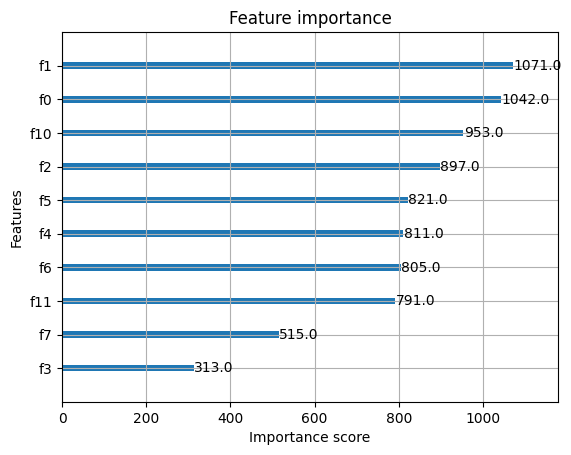

In [70]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model_xgb, max_num_features=10)
plt.show()

In [72]:
feature_names = preprocessor.get_feature_names_out()

importances = model_xgb.feature_importances_

feat_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_importance.head(10))

                             feature  importance
0                 num__log_followers    0.048383
50  cat__sentiment_category_Positive    0.046746
16             cat__platform_Twitter    0.019107
13           cat__platform_Instagram    0.018527
14              cat__platform_Reddit    0.018370
19               cat__topic_Business    0.018112
25                   cat__topic_Food    0.017979
33              cat__language_Arabic    0.017728
40              cat__language_Korean    0.017635
4            num__sentiment_positive    0.017629


B. Build network graph

B1 . User - User

Node = user

Edge = users có điểm chung (topic, platform, language, location)

→ extract centrality features

In [48]:
from sklearn.model_selection import train_test_split

# Chia df gốc thành df_train và df_test
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

print("Đã chia dữ liệu thành df_train và df_test thành công!")

Đã chia dữ liệu thành df_train và df_test thành công!


In [49]:
import networkx as nx
from itertools import combinations

# 1. Khởi tạo Graph
G_user = nx.Graph()

# 2. Thêm nodes từ df_train (đã sửa tên biến từ X_train_df thành df_train)
users_train = df_train['user_id'].unique()
G_user.add_nodes_from(users_train)

print(f"Total users in Train: {len(users_train)}")

# 3. Hàm xây dựng cạnh (Đảm bảo dùng đúng các cột trong df_train)
def build_user_graph_from_context(data_source):
    print("Đang tạo các kết nối User-User...")
    # Gom nhóm theo các tiêu chí bạn muốn (location, topic, thời gian)
    groups = data_source.groupby(['date', 'hour_of_day', 'topic', 'location'])
    
    for name, group in groups:
        user_list = group['user_id'].unique()
        if 1 < len(user_list) < 50: 
            for u1, u2 in combinations(user_list, 2):
                if G_user.has_edge(u1, u2):
                    G_user[u1][u2]['weight'] += 1
                else:
                    G_user.add_edge(u1, u2, weight=1)

# 4. Gọi hàm truyền vào df_train
build_user_graph_from_context(df_train)

print(f"Total edges created: {G_user.number_of_edges()}")

Total users in Train: 106691
Đang tạo các kết nối User-User...
Total edges created: 69556


In [74]:
# =========================
# GRAPH FEATURES
# =========================

print("Calculating degree...")
degree_dict = dict(G.degree())

print("Calculating pagerank...")
pagerank_dict = nx.pagerank(G, alpha=0.85)

print("Calculating clustering...")
clustering_dict = nx.clustering(G)

# betweenness hơi nặng → optional
print("Calculating betweenness (sample)...")
betweenness_dict = nx.betweenness_centrality(G, k=100)  # sample để nhanh

Calculating degree...
Calculating pagerank...
Calculating clustering...
Calculating betweenness (sample)...


In [50]:
import numpy as np

# Tạo cột log_followers từ cột followers gốc (cộng 1 để tránh lỗi log(0))
if 'log_followers' not in df_train.columns:
    df_train['log_followers'] = np.log1p(df_train['followers'])

# Bây giờ mới chạy lệnh xuất file Nodes
nodes_df = pd.DataFrame({'Id': list(G_user.nodes())})

node_info = df_train.groupby('user_id').agg({
    'platform': 'first',
    'location': 'first',
    'log_followers': 'mean',
    'topic': 'first'
}).reset_index()

node_info.rename(columns={'user_id': 'Id'}, inplace=True)
nodes_df = nodes_df.merge(node_info, on='Id', how='left')

nodes_df.to_csv("nodes_cross_platform.csv", index=False)
print("Đã xuất file nodes thành công!")

Đã xuất file nodes thành công!


In [51]:
import pandas as pd

# ==========================================
# 1. XUẤT FILE NODES (Nodes.csv)
# ==========================================
# Lấy danh sách các node hiện có trong đồ thị G_user
nodes_df = pd.DataFrame({'Id': list(G_user.nodes())})

# Lấy thông tin bổ trợ từ df_train (giữ lại platform để Gephi phân màu)
# Chúng ta dùng 'first' cho platform và location vì giả định 1 user_id gắn với 1 profile
node_info = df_train.groupby('user_id').agg({
    'platform': 'first',
    'location': 'first',
    'log_followers': 'mean',
    'topic': 'first'
}).reset_index()

node_info.rename(columns={'user_id': 'Id'}, inplace=True)

# Merge thông tin vào danh sách node
nodes_df = nodes_df.merge(node_info, on='Id', how='left')

# Lưu file Nodes
nodes_df.to_csv("nodes_cross_platform.csv", index=False)
print(f"Đã xuất {len(nodes_df)} nodes vào file nodes_cross_platform.csv")


# ==========================================
# 2. XUẤT FILE EDGES (Edges.csv)
# ==========================================
edges_list = []

# Duyệt qua các cạnh trong đồ thị để lấy Source, Target và Weight
for u, v, data in G_user.edges(data=True):
    edges_list.append({
        'Source': u,
        'Target': v,
        'Weight': data.get('weight', 1),
        'Type': 'Undirected' # Đồ thị vô hướng cho tính chất "xuất hiện chung"
    })

edges_df = pd.DataFrame(edges_list)

# Lưu file Edges
edges_df.to_csv("edges_cross_platform.csv", index=False)
print(f"Đã xuất {len(edges_df)} edges vào file edges_cross_platform.csv")

Đã xuất 106691 nodes vào file nodes_cross_platform.csv
Đã xuất 69556 edges vào file edges_cross_platform.csv


In [43]:
print(df_train.columns)

Index(['post_id', 'platform', 'timestamp', 'date', 'hour_of_day',
       'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days',
       'verified', 'topic', 'language', 'content_length', 'media_type',
       'num_hashtags', 'sentiment_category', 'sentiment_positive',
       'sentiment_negative', 'sentiment_neutral', 'likes', 'shares',
       'comments', 'views', 'total_engagement',
       'engagement_rate_per_1k_followers', 'hours_since_post',
       'viral_coefficient', 'cross_platform_spread', 'toxicity_score',
       'location'],
      dtype='object')


In [53]:
# Chạy dòng này để xem danh sách cột
print("Các cột trong tập Train:")
print(df_train.columns.tolist())

# Kiểm tra kiểu dữ liệu của một vài cột
print("\nThông tin chi tiết:")
print(df_train.info())

Các cột trong tập Train:
['post_id', 'platform', 'timestamp', 'date', 'hour_of_day', 'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days', 'verified', 'topic', 'language', 'content_length', 'media_type', 'num_hashtags', 'sentiment_category', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'likes', 'shares', 'comments', 'views', 'total_engagement', 'engagement_rate_per_1k_followers', 'hours_since_post', 'viral_coefficient', 'cross_platform_spread', 'toxicity_score', 'location', 'log_followers', 'pageranks', 'modularity_class', 'Degree', 'Weighted Degree', 'betweenesscentrality', 'eigencentrality', 'clustering']

Thông tin chi tiết:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 39 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   post_id                           120000 non-null  object 
 1   platform         

In [52]:
# 1. Đọc file kết quả từ Gephi
df_gephi = pd.read_csv('gephi-result-3.csv')

# 2. Chọn các đặc trưng 'đắt giá' nhất cho mô hình
graph_features = [
    'pageranks', 'modularity_class', 'Degree', 
    'Weighted Degree', 'betweenesscentrality', 
    'eigencentrality', 'clustering'
]

# 3. Nối vào tập dữ liệu gốc (df_train và df_test)
# Id trong Gephi tương ứng với user_id trong dữ liệu của bạn
df_gephi_subset = df_gephi[['Id'] + graph_features]

# Merge vào df_train
df_train = df_train.merge(df_gephi_subset, left_on='user_id', right_on='Id', how='left').fillna(0)
# Merge vào df_test
df_test = df_test.merge(df_gephi_subset, left_on='user_id', right_on='Id', how='left').fillna(0)

# Xóa cột Id thừa sau khi merge
df_train.drop(columns=['Id'], inplace=True)
df_test.drop(columns=['Id'], inplace=True)

In [54]:
df_train.head()

,post_id,platform,timestamp,date,hour_of_day,day_of_week,is_weekend,user_id,followers,account_age_days,...,toxicity_score,location,log_followers,pageranks,modularity_class,Degree,Weighted Degree,betweenesscentrality,eigencentrality,clustering
0,TWI20250529104025,Twitter,2025-05-29 13:02:41,2025-05-29,13,3,0,user_32621,1394,2539,...,45.6,North America,7.240650,0.000014,14358,2,2,0,0.002119,1.0
1,TWI20250429005415,Twitter,2025-04-29 20:05:46,2025-04-29,20,1,0,user_49267,21,3440,...,0.0,South America,3.091042,0.000002,0,0,0,0,0.000000,0.0
2,TWI20250915075612,Twitter,2025-09-15 14:21:00,2025-09-15,14,0,0,user_116224,1967,2333,...,0.0,Asia,7.584773,0.000014,22943,1,1,0,0.000800,0.0
3,TWI20250912138169,Twitter,2025-09-12 14:53:21,2025-09-12,14,4,0,user_173996,4452,3281,...,1.0,North America,8.401333,0.000002,1,0,0,0,0.000000,0.0
4,RED20251005087184,Reddit,2025-10-05 15:38:44,2025-10-05,15,6,1,user_201834,249,2292,...,24.9,Europe,5.521461,0.000014,38070,2,2,0,0.002355,1.0


In [56]:
# Cập nhật danh sách numerical bao gồm các thuộc tính Gephi
numerical_cols = [
    'log_followers', 'account_age_days', 'content_length', 'num_hashtags',
    'sentiment_positive', 'sentiment_negative', 'sentiment_neutral',
    'hour_of_day', 'day_of_week', 'hours_since_post', 'toxicity_score',
    # Các đặc trưng từ Gephi
    'pageranks', 'Degree', 'Weighted Degree', 
    'betweenesscentrality', 'eigencentrality', 'clustering'
]

# Các biến phân loại (Thêm modularity_class nếu muốn)
categorical_cols = [
    'platform', 'topic', 'language', 'media_type', 
    'sentiment_category', 'location', 'modularity_class','modularity_class'
]

In [ ]:
# --- Cập nhật danh sách từ ảnh image_1e5f21.png ---

# 1. Thêm các cột từ Gephi vào numerical_cols
new_graph_numerical = [
    'pageranks', 'Degree', 'Weighted Degree', 
    'betweenesscentrality', 'eigencentrality', 'clustering'
]

numerical_cols = [
    'log_followers', 'account_age_days', 'content_length', 'num_hashtags',
    'sentiment_positive', 'sentiment_negative', 'sentiment_neutral',
    'hour_of_day', 'day_of_week', 'hours_since_post', 'toxicity_score'
] + new_graph_numerical # Cộng dồn thêm các cột Gephi vào đây

# 2. Thêm modularity_class vào categorical (nếu muốn)
categorical_cols = [
    'platform', 'topic', 'language', 'media_type', 
    'sentiment_category', 'location', 'modularity_class'
]

In [ ]:


# --- Định nghĩa lại bộ xử lý ---
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# --- THAY ĐỔI QUAN TRỌNG: Fit trên df_train đã merge dữ liệu Gephi ---
# Đừng dùng X_processed = preprocessor.fit_transform(X_df) nữa
X_train_final = preprocessor.fit_transform(df_train)
X_test_final = preprocessor.transform(df_test) # Dùng transform thôi để tránh leakage

y_train = df_train['label']
y_test = df_test['label']

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Định nghĩa bộ tiền xử lý
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# 2. Fit và transform TRÊN TẬP TRAIN
X_train_final = preprocessor.fit_transform(df_train)

# 3. CHỈ TRANSFORM trên tập Test (để dùng thông số mean/std của tập Train)
X_test_final = preprocessor.transform(df_test)

# 4. Lấy Label
y_train = df_train['label']
y_test = df_test['label']

print("Dữ liệu đã sẵn sàng để Train!")

ValueError: columns are missing: {'log_followers'}

In [41]:
# =========================
# EXPORT NODE FILE
# =========================

nodes_df = pd.DataFrame({
    'Id': list(G_user.nodes())
})

# (optional) thêm info cho đẹp trong Gephi
node_info = df.groupby('user_id').agg({
    'topic': 'first',
    'language': 'first',
    'location': 'first'
}).reset_index()

node_info.rename(columns={'user_id': 'Id'}, inplace=True)

nodes_df = nodes_df.merge(node_info, on='Id', how='left')

# save
nodes_df.to_csv("nodes.csv", index=False)

print("Nodes exported:", nodes_df.shape)

Nodes exported: (106691, 4)


In [40]:
# =========================
# EXPORT EDGE FILE
# =========================

edges_df = pd.DataFrame(G_user.edges(), columns=['Source', 'Target'])

# optional: add weight = 1
edges_df['Weight'] = 1

edges_df.to_csv("edges.csv", index=False)

print("Edges exported:", edges_df.shape)

Edges exported: (69556, 3)


In [75]:
# load file gephi
graph_df = pd.read_csv("gephi-result-2.csv")

In [76]:
graph_df.head()

,Id,platform,topic,language,location,pageranks,Authority,Hub,modularity_class,stat_inf_class,...,Eccentricity,closnesscentrality,harmonicclosnesscentrality,betweenesscentrality,weighted indegree,weighted outdegree,Weighted Degree,indegree,outdegree,Degree
0,user_426711,TikTok,Finance,English,Asia,0.000007,0.000000,0.067535,8,183,...,2,0.544640,0.581963,0.000000,0,329,329,0,329,329
1,user_221610,Twitter,Food,English,South America,0.000007,0.000473,0.065736,5,605,...,2,0.547665,0.587032,13.250414,1,349,350,1,349,350
2,user_7998,Instagram,Sports,Spanish,Europe,0.000007,0.000000,0.074908,1,290,...,2,0.544837,0.582294,0.000000,0,330,330,0,330,330
3,user_313440,Instagram,Education,English,Europe,0.000007,0.001458,0.068020,79,200,...,2,0.543237,0.579591,22.323538,3,319,322,3,319,322
4,user_23343,Reddit,Gaming,French,Asia,0.000007,0.000473,0.072729,10,305,...,3,0.547990,0.587741,10.141397,1,352,353,1,352,353


In [77]:

# rename cho dễ
graph_df = graph_df.rename(columns={
    'Id': 'user_id',
    'pageranks': 'pagerank',
    'Degree': 'degree',
    'betweenesscentrality': 'betweenness',
    'closnesscentrality': 'closeness',
    'clustering': 'clustering',
    'Authority': 'authority',
    'Hub': 'hub',
    'modularity_class': 'community'
})

graph_features = graph_df[[
    'user_id',
    'pagerank',
    'degree',
    'betweenness',
    'closeness',
    'clustering',
    'authority',
    'hub',
    'community'
]]

In [78]:

# merge
df = df.merge(graph_features, on='user_id', how='left')

print("After merge:", df.shape)

After merge: (150000, 37)


In [81]:
# rebuild X_df sau khi có graph features
X_df = df.drop(columns=['target_engagement', 'label'])

In [82]:
numerical_cols += [
    'pagerank', 'degree', 'betweenness',
    'closeness', 'clustering', 'authority', 'hub'
]

categorical_cols += ['community']

In [83]:
numerical_cols = [col for col in numerical_cols if col in X_df.columns]
categorical_cols = [col for col in categorical_cols if col in X_df.columns]

In [84]:
cols_to_drop = [col for col in df.columns if any(x in col for x in [
    'pagerank', 'degree', 'betweenness', 'closeness',
    'clustering', 'authority', 'hub', 'community'
])]

df = df.drop(columns=cols_to_drop)

print("After clean:", df.columns)

After clean: Index(['platform', 'date', 'hour_of_day', 'day_of_week', 'is_weekend',
       'user_id', 'followers', 'account_age_days', 'verified', 'topic',
       'language', 'content_length', 'media_type', 'num_hashtags',
       'sentiment_category', 'sentiment_positive', 'sentiment_negative',
       'sentiment_neutral', 'views', 'hours_since_post',
       'cross_platform_spread', 'toxicity_score', 'location', 'hour', 'day',
       'month', 'log_followers', 'target_engagement', 'label'],
      dtype='object')


In [86]:
X_processed = preprocessor.fit_transform(X_df)

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_clf, y_test_clf = train_test_split(
    X_processed, y_clf, test_size=0.2, random_state=42
)

In [88]:
from xgboost import XGBClassifier
# =========================
# 2. TRAIN MODEL
# =========================
model_xgb.fit(X_train, y_train_clf)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [89]:
# =========================
# 3. PREDICT
# =========================
y_pred = model_xgb.predict(X_test)
y_prob = model_xgb.predict_proba(X_test)[:, 1]

print("\nBaseline 4 (XGBoost) with graph features:")
print("Accuracy:", accuracy_score(y_test_clf, y_pred))
print("F1-score:", f1_score(y_test_clf, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_clf, y_prob))



Baseline 4 (XGBoost) with graph features:
Accuracy: 0.5056666666666667
F1-score: 0.32901999819020905
ROC-AUC: 0.5694240929821072


B2. Topic - Topic graph

In [90]:
import pandas as pd
import networkx as nx


# 2. Xây dựng đồ thị (Graph Construction)
G1 = nx.Graph()

# Tạo danh sách các nhóm dựa trên location, sentiment và hour
# Nhóm theo: [location, sentiment_category, hour_of_day]
groups = df.groupby(['location', 'sentiment_category', 'hour_of_day'])

for name, group in groups:
    topics = group['topic'].unique()
    if len(topics) > 1:
        # Tạo cạnh giữa tất cả các cặp topic xuất hiện cùng nhau trong nhóm này
        from itertools import combinations
        for t1, t2 in combinations(topics, 2):
            if G1.has_edge(t1, t2):
                G1[t1][t2]['weight'] += 1
            else:
                G1.add_edge(t1, t2, weight=1)

# 3. Trích xuất đặc trưng (Feature Extraction)
# Tính PageRank cho mỗi Topic
pagerank_scores = nx.pagerank(G1, weight='weight')

# Ánh xạ PageRank score ngược lại vào dataframe chính
df['topic_pagerank'] = df['topic'].map(pagerank_scores).fillna(0)

print(f"Hoàn thành tính PageRank. Top 5 Topic quan trọng: {sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:5]}")

Hoàn thành tính PageRank. Top 5 Topic quan trọng: [('Food', 0.06732512188430068), ('Finance', 0.0672126928919192), ('Education', 0.06721266225185912), ('Science', 0.06720139917570186), ('Climate', 0.06697661534968102)]


In [ ]:
import pandas as pd
import networkx as nx
from itertools import combinations

# 1. Chia Train/Test TRƯỚC khi tính toán bất kỳ đặc trưng đồ thị nào
# Sử dụng GroupShuffleSplit theo User như báo cáo đã nêu [cite: 151, 188]
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df['user_id'])) # Giả sử có user_id

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

def calculate_dynamic_pagerank(input_df):
    dynamic_features = []
    input_df['month'] = pd.to_datetime(input_df['date']).dt.to_period('M')
    
    for month in input_df['month'].unique():
        month_df = input_df[input_df['month'] == month]
        G_month = nx.Graph()
        
        # Nhóm theo ngữ cảnh để xây dựng cạnh [cite: 73]
        groups = month_df.groupby(['location', 'sentiment_category', 'hour_of_day'])
        
        for _, group in groups:
            topics = group['topic'].unique()
            if len(topics) > 1:
                # Trích xuất trọng số từ các tín hiệu hợp lệ (không rò rỉ) [cite: 185]
                weight = (group['log_followers'].mean() + group['sentiment_positive'].mean())
                for t1, t2 in combinations(topics, 2):
                    if G_month.has_edge(t1, t2):
                        G_month[t1][t2]['weight'] += weight
                    else:
                        G_month.add_edge(t1, t2, weight=weight)
        
        # Tính PageRank động [cite: 16, 74]
        if len(G_month) > 0:
            pagerank_month = nx.pagerank(G_month, weight='weight')
            for topic, score in pagerank_month.items():
                dynamic_features.append({'month': month, 'topic': topic, 'dynamic_pagerank': score})
    
    return pd.DataFrame(dynamic_features)

# 2. Chỉ tính toán trên tập Train
df_dynamic_train = calculate_dynamic_pagerank(train_df)

# 3. Ánh xạ kết quả vào cả Train và Test

# Kiểm tra và xóa cột dynamic_pagerank cũ nếu nó đã tồn tại để tránh lỗi duplicate
if 'dynamic_pagerank' in train_df.columns:
    train_df = train_df.drop(columns=['dynamic_pagerank'])
if 'dynamic_pagerank' in test_df.columns:
    test_df = test_df.drop(columns=['dynamic_pagerank'])

# Thực hiện merge lại
train_df = train_df.merge(df_dynamic_train, on=['month', 'topic'], how='left').fillna(0)
test_df = test_df.merge(df_dynamic_train, on=['month', 'topic'], how='left').fillna(0)


print("Hoàn thành tính toán tránh Leakage.")

Hoàn thành tính toán tránh Leakage và đã xử lý trùng cột.
Hoàn thành tính toán tránh Leakage.


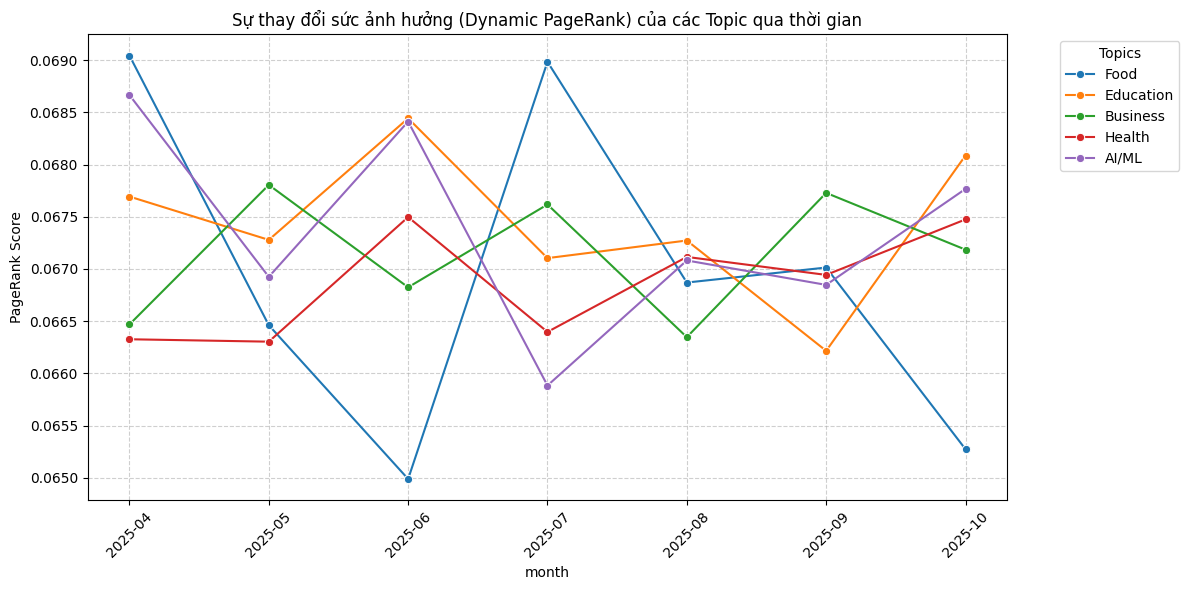

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chuẩn bị dữ liệu: Lấy Top 5 topic có trung bình PageRank cao nhất để vẽ cho đỡ rối
top_topics = df.groupby('topic')['dynamic_pagerank'].mean().nlargest(5).index
plot_df = df[df['topic'].isin(top_topics)].drop_duplicates(['month', 'topic']).sort_values('month')

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x=plot_df['month'].astype(str), y='dynamic_pagerank', hue='topic', marker='o')
plt.title('Sự thay đổi sức ảnh hưởng (Dynamic PageRank) của các Topic qua thời gian')
plt.xticks(rotation=45)
plt.ylabel('PageRank Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Topics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [93]:
# =========================
# 1. BUILD DATA (ONLY dynamic)
# =========================

# chọn feature (không dùng graph user)
features_dynamic = [
    'followers', 'log_followers', 'content_length',
    'num_hashtags', 'sentiment_positive',
    'sentiment_negative', 'sentiment_neutral', 'hours_since_post',
    'cross_platform_spread', 'toxicity_score',
    'dynamic_pagerank'
]

categorical_cols_dyn = [
    'platform', 'topic', 'language',
    'media_type', 'sentiment_category', 'location'
]

X_dyn = df[features_dynamic + categorical_cols_dyn]
y_dyn = df['label']

In [94]:
# =========================
# 2. PREPROCESS
# =========================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_dyn = ColumnTransformer([
    ('num', StandardScaler(), features_dynamic),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_dyn)
])

X_dyn_processed = preprocessor_dyn.fit_transform(X_dyn)

In [95]:
# =========================
# 3. SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_dyn_processed, y_dyn, test_size=0.2, random_state=42
)

In [96]:
# =========================
# 4. TRAIN
# =========================

from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_dyn = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model_dyn.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [97]:
# =========================
# 5. EVALUATE
# =========================

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

y_pred = model_dyn.predict(X_test)
y_prob = model_dyn.predict_proba(X_test)[:, 1]

print("\nDynamic Only Model:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Dynamic Only Model:
Accuracy: 0.5581666666666667
F1: 0.3192440039032407
ROC-AUC: 0.5768680402410692


In [87]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X_dyn, y_dyn, groups=df['user_id']))

X_train_df = X_dyn.iloc[train_idx]
X_test_df = X_dyn.iloc[test_idx]

y_train = y_dyn.iloc[train_idx]
y_test = y_dyn.iloc[test_idx]

In [66]:
print(df[['dynamic_pagerank', 'label']].corr())

                  dynamic_pagerank     label
dynamic_pagerank          1.000000 -0.001031
label                    -0.001031  1.000000


In [67]:
train_users = set(df.iloc[X_train.indices]['user_id'])
test_users = set(df.iloc[X_test.indices]['user_id'])

print(len(train_users & test_users))

57


In [89]:
leak_cols = [
    'views',
    'likes',
    'comments',
    'engagement_rate_per_1k_followers',
    'viral_coefficient'
]

for col in leak_cols:
    print(col, col in X_df.columns)

views True
likes False
comments False
engagement_rate_per_1k_followers False
viral_coefficient False


Final train

In [138]:
# =========================
# 1. SELECT FEATURE
# =========================

numerical_cols_final = [
    # user
    'followers', 'log_followers', 'account_age_days',

    # content
    'content_length', 'num_hashtags',

    # sentiment
    'sentiment_positive', 'sentiment_negative', 'sentiment_neutral',

    # timing
    'hours_since_post',

    # spread
    'cross_platform_spread',

    # safety
    'toxicity_score',

    # 🔥 USER GRAPH
    'pagerank', 'degree', 'betweenness',
    'closeness', 'clustering', 'authority', 'hub',

    # 🔥 DYNAMIC
    'dynamic_pagerank'
]

categorical_cols_final = [
    'platform', 'topic', 'language',
    'media_type', 'sentiment_category',
    'location', 'community'
]

# safety check
numerical_cols_final = [c for c in numerical_cols_final if c in df.columns]
categorical_cols_final = [c for c in categorical_cols_final if c in df.columns]

X_df = df[numerical_cols_final + categorical_cols_final]
y = df['label']

In [139]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X_df, y, groups=df['user_id']))

X_train_df = X_df.iloc[train_idx]
X_test_df = X_df.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [140]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols_final),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_final)
])

X_train = preprocessor.fit_transform(X_train_df)
X_test = preprocessor.transform(X_test_df)

In [141]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_final = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model_final.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [5]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

y_pred = model_final.predict(X_test)
y_prob = model_final.predict_proba(X_test)[:, 1]

print("\nFINAL MODEL (CLEAN):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

NameError: name 'model_final' is not defined

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

NameError: name 'X_train' is not defined

In [98]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

# Chuyển đổi NetworkX G1 thành dữ liệu PyG
# Giả sử G1 của bạn có các node là các Topic
pyg_data = from_networkx(G1)

# Tạo thuộc tính cho các nút (x): dùng chính metadata trung bình của Topic đó
# Hoặc đơn giản là dùng ma trận đơn vị nếu chưa có thuộc tính nút cụ thể
node_features = []
topic_list = list(G1.nodes())
for topic in topic_list:
    # Lấy trung bình các feature của posts thuộc topic này
    avg_feat = df[df['topic'] == topic][features_dynamic].mean().values
    node_features.append(avg_feat)

pyg_data.x = torch.tensor(node_features, dtype=torch.float)

In [99]:
class TopicGCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels):
        super(TopicGCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)

    def forward(self, data):
        x, edge_index, edge_weight = data.x, data.edge_index, data.edge_attr
        
        # Lớp GCN 1
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        
        # Lớp GCN 2 -> tạo Embedding
        x = self.conv2(x, edge_index, edge_weight)
        return x

# Khởi tạo và lấy Embeddings
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_gcn = TopicGCN(num_node_features=len(features_dynamic), hidden_channels=32).to(device)
pyg_data = pyg_data.to(device)

with torch.no_grad():
    topic_embeddings = model_gcn(pyg_data).cpu().numpy()

# Ánh xạ embedding về dataframe
embedding_dict = {topic: topic_embeddings[i] for i, topic in enumerate(topic_list)}

In [100]:
import numpy as np

# Tạo ma trận embedding cho từng dòng trong df
gcn_feats = np.array([embedding_dict.get(t, np.zeros(16)) for t in df['topic']])

# Nối Metadata + Dynamic PageRank + GCN Embeddings
# X_dyn_processed của bạn đang là sparse matrix từ ColumnTransformer, cần chuyển sang dense hoặc hstack
from scipy.sparse import hstack

X_final = hstack([X_dyn_processed, gcn_feats])

# Chia lại tập dữ liệu với Feature mới
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_dyn, test_size=0.2, random_state=42, stratify=y_dyn
)

# Train với XGBoost (như trong báo cáo mục 3.4)
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score

final_model = XGBClassifier(n_estimators=100, learning_rate=0.05)
final_model.fit(X_train_f, y_train_f)

y_pred = final_model.predict(X_test_f)
print(f"F1 Score mới với GCN: {f1_score(y_test_f, y_pred):.3f}")

F1 Score mới với GCN: 0.072


========== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ==========
Accuracy: 0.8063
F1-Score: 0.0716
ROC-AUC:  0.5878

Báo cáo chi tiết:
              precision    recall  f1-score   support

           0       0.81      1.00      0.89     24002
           1       0.86      0.04      0.07      5998

    accuracy                           0.81     30000
   macro avg       0.83      0.52      0.48     30000
weighted avg       0.82      0.81      0.73     30000



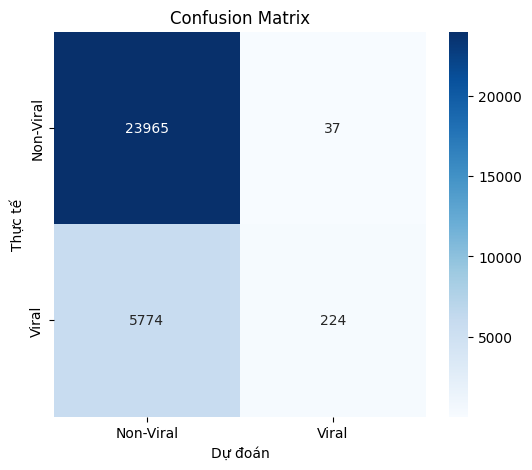

In [101]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dự đoán trên tập Test
# Chú ý: y_pred dùng cho Accuracy/F1, y_probs dùng cho ROC-AUC
y_pred = final_model.predict(X_test_f)
y_probs = final_model.predict_proba(X_test_f)[:, 1] # Xác suất của lớp positive (viral)

# 2. Tính toán các chỉ số chính
accuracy = accuracy_score(y_test_f, y_pred)
f1 = f1_score(y_test_f, y_pred)
roc_auc = roc_auc_score(y_test_f, y_probs)

print("========== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ==========")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}") # Chỉ số chính nhóm ưu tiên [cite: 192]
print(f"ROC-AUC:  {roc_auc:.4f}")
print("==============================================")

# 3. Chi tiết báo cáo phân loại (Precision, Recall cho từng lớp)
# Giúp phân tích tại sao mô hình khó dự đoán viral content [cite: 225]
print("\nBáo cáo chi tiết:")
print(classification_report(y_test_f, y_pred))

# 4. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_f, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Viral', 'Viral'], 
            yticklabels=['Non-Viral', 'Viral'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix')
plt.show()